[HIP_65_A] Not enough data:
  inner count (<30 pc): 12
  outer count (60–90 pc): 0


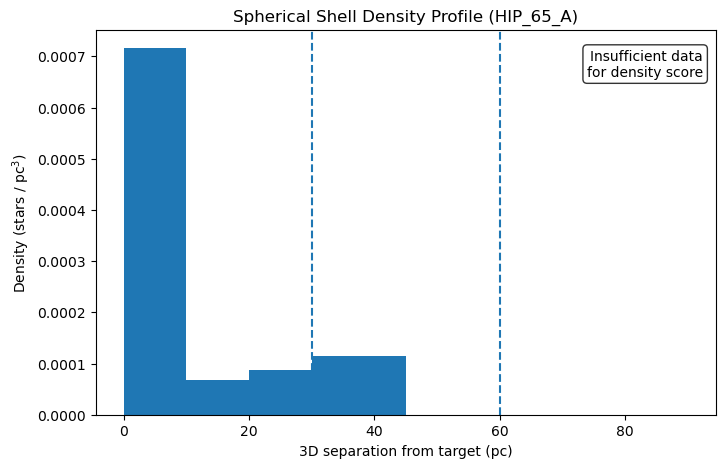

hostname = HIP_65_A
{'density_ratio': None, 'density_score': None, 'n_inner': 12, 'n_outer': 0}


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


def load_friendfinder_csv(csv_path, required_columns=None):
    if required_columns is None:
        required_columns = ["3D(pc)", "Sep(deg)", "Voff(km/s)"]

    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()

    missing_cols = [col for col in required_columns if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing columns: {missing_cols}")

    arrays = {}
    for col in required_columns:
        arrays[col] = pd.to_numeric(df[col], errors="coerce").to_numpy()

    hostname = Path(csv_path).stem
    return arrays, hostname


def spherical_density_analysis(r_3d, hostname="Target"):
    r_3d = np.asarray(r_3d, dtype=float)
    r_3d = r_3d[np.isfinite(r_3d)]

    # --- Histogram bins ---
    bins = np.array([0, 10, 20, 30, 45, 60, 70, 90], dtype=float)
    counts, edges = np.histogram(r_3d, bins=bins)

    # --- Volume-corrected densities ---
    shell_volumes = (4.0 / 3.0) * np.pi * (edges[1:]**3 - edges[:-1]**3)
    densities = counts / shell_volumes

    # --- Plot ---
    plt.figure(figsize=(8, 5))
    plt.stairs(densities, edges, fill=True)
    plt.xlabel("3D separation from target (pc)")
    plt.ylabel("Density (stars / pc$^3$)")
    plt.title(f"Spherical Shell Density Profile ({hostname})")
    plt.axvline(30, linestyle="--")
    plt.axvline(60, linestyle="--")

    # --- Inner / outer regions ---
    inner_mask = r_3d < 30
    outer_mask = (r_3d > 60) & (r_3d <= 90)

    n_inner = np.sum(inner_mask)
    n_outer = np.sum(outer_mask)

    # --- Only compute score if both regions have data ---
    if n_inner > 0 and n_outer > 0:
        v_inner = (4.0 / 3.0) * np.pi * (30.0**3)
        v_outer = (4.0 / 3.0) * np.pi * (90.0**3 - 60.0**3)

        inner_density = n_inner / v_inner
        outer_density = n_outer / v_outer

        density_ratio = inner_density / outer_density
        density_score = inner_density / (inner_density + outer_density)

        plt.text(
            0.98, 0.95,
            f"Score = {density_score:.3f}",
            transform=plt.gca().transAxes,
            ha="right",
            va="top",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
        )

    else:
        density_ratio = None
        density_score = None

        plt.text(
            0.98, 0.95,
            "Insufficient data\nfor density score",
            transform=plt.gca().transAxes,
            ha="right",
            va="top",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
        )

        print(f"[{hostname}] Not enough data:")
        print(f"  inner count (<30 pc): {n_inner}")
        print(f"  outer count (60–90 pc): {n_outer}")

    plt.show()

    return {
        "density_ratio": density_ratio,
        "density_score": density_score,
        "n_inner": n_inner,
        "n_outer": n_outer,
    }


# --- Run ---
csv_path = r"FRIENDS\HIP_65_A.csv"

arrays, hostname = load_friendfinder_csv(csv_path)

r_3d = arrays["3D(pc)"]

results = spherical_density_analysis(r_3d, hostname)

print("hostname =", hostname)
print(results)